In [4]:
import pandas as pd
import protfasta
import matplotlib.pyplot as plt
import seaborn as sns
#import Levenshtein

# 1. Loading in all DBD sequences

In [5]:
DBD_sql_dump = pd.read_csv("../data/DBD_sql_dump.csv")
DBD_sql_dump = DBD_sql_dump.drop_duplicates(subset = "ProtFeature_Sequence")
DBD_sql_dump

,Unnamed: 0,PFeature_ID,Protein_ID,Domain_ID,ProtFeature_FromPos,ProtFeature_ToPos,ProtFeature_Sequence,Domain_Name,Pfam_Name,Pfam_DBID,Inter_DBID,Domain_Type
0,0,PF000001_2.00,P000002_2.00,D08_2.00,46,137,PTSRLQAPRFPLLKVIPEWVINHFGRNIVGSIKLEAPNGNIYDVGV...,B3,B3,PF02362,IPR003340,DBD
1,1,PF000002_2.00,P000002_2.00,D08_2.00,194,293,LVVLMKKSNVNHNFTLIIRKDYAREYFPPKNTTIILQLPGKSKHWN...,B3,B3,PF02362,IPR003340,DBD
2,2,PF000003_2.00,P000002_2.00,D01_2.00,327,442,KEEPIIDESTKTALTPRVKEEPTIDGTGVRHISNHIFSIHCPCQIH...,ABF1,BAF1_ABF1,PF04684,IPR006774,DBD
3,3,PF000004_2.00,P000002_2.00,D08_2.00,507,611,VHKRGSPSPVFSSQYISRYLAEKYATGLTGVRGRRGAISLLLERDG...,B3,B3,PF02362,IPR003340,DBD
4,4,PF000005_2.00,P000003_2.00,D08_2.00,231,323,QAEKKAILPKPKEEYEYDNDGKKKKNKESHGLEVMAYDRTGEPYNL...,B3,B3,PF02362,IPR003340,DBD
...,...,...,...,...,...,...,...,...,...,...,...,...
993305,993305,PF993306_2.00,P436312_2.00,D89_2.00,33,70,LSCVPCHQRKIKCSRDQPACSNCLKNNWDCVYFLNDRI,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993306,993306,PF993307_2.00,P436313_2.00,D89_2.00,19,57,LGCTECKRRKVKCDETKPMCWQCSHLGKNCVYSSPSTRI,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993307,993307,PF993308_2.00,P436314_2.00,D89_2.00,16,54,FACQSCRKRKRKCDRKKPVCERCKRLGVPCVYELPPKHL,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993364,993364,PF993365_2.00,P436370_2.00,D89_2.00,303,323,YTVGKPCSRCAKFNKKCEDAL,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD


# 2. Loading in all AD annotations

In [6]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical_with_alerasool.csv", index_col = 0)
known_ADs

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq
0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,"DelRosso et al. (Q6UWZ7, 121_200)",CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...
1,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,LLQALNGFV
2,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,FAI
3,AHR,532,848,P35869,"[['P35869'], ['P35869'], ['P35869']]",ENST00000242057 / nan / ENST00000242057,P35869 / P35869 / P35869,"DelRosso et al. (P35869, 532_641) // PMID: 879...",TF / TF / TF,QDSKNSDLYSIMKNLGIDFEDIRHMQNEKFFRNDFSGEVDFRDIDL...
4,AKAP8,2,81,O43823,[['O43823']],ENST00000269701,O43823,"DelRosso et al. (O43823, 2_81)",TF,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...
...,...,...,...,...,...,...,...,...,...,...
757,ATXN7L3,1,120,Q14CW9,"[['Q14CW9', 'Q14CW9-2']]",NaN,NaN,Alerasool et al,TF,MKMEEMSLSGLDNSKLEAIAQEIYADLVEDSCLGFCFEVHRAVKCG...
758,FAM22F,361,500,A1L443,[['A1L443']],NaN,NaN,Alerasool et al,TF,PRPQRPAETNAHLPPPRPQRPAETKVPEEIPPEVVQEYVDIMEELL...
759,SS18L2,18,77,Q9UHA2,[['Q9UHA2']],NaN,NaN,Alerasool et al,TF,QETIQRLLEENDQLIRCIVEYQNKGRGNECVQYQHVLHRNLIYLAT...
760,SERTAD2,201,260,Q14140,[['Q14140']],NaN,NaN,Alerasool et al,TF,SEAGTQKLDGPQESRADDSKLMDSLPGNFEITTSTGFLTDLTLDDI...


# 3. Downloading all isoforms of Lambert TF genes

In [7]:
lambert_isoforms = protfasta.read_fasta("../data/all_lambert_TF_isoforms.txt")
lambert_isoforms = pd.DataFrame({"id": lambert_isoforms.keys(), "seq" : lambert_isoforms.values()})
lambert_isoforms

,id,seq
0,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...
1,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...
2,sp|A0PJY2-2|FEZF1_HUMAN Isoform 2 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...
3,sp|A0PJY2-3|FEZF1_HUMAN Isoform 3 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...
4,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...
...,...,...
3526,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...
3527,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...
3528,sp|Q9Y6Y1-2|CMTA1_HUMAN Isoform 2 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...
3529,sp|Q9Y6Y1-3|CMTA1_HUMAN Isoform 3 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...


# Get domain alignment scores

In [8]:
# List of DBD sequences
lambert_TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
lambert_TFs["DBD_coords_merged"] = lambert_TFs["DBD_coords_merged"].str.split("],")
lambert_TFs = lambert_TFs.explode("DBD_coords_merged")
lambert_TFs = lambert_TFs.dropna()
lambert_TFs["Start"] = lambert_TFs["DBD_coords_merged"].str.extract(r'(\d+), \d+').astype(int)
lambert_TFs["End"] = lambert_TFs["DBD_coords_merged"].str.extract(r'\d+, (\d+)').astype(int)
lambert_TFs = lambert_TFs.drop(columns = "DBD_coords_merged")
lambert_TFs["uniprotID"] = lambert_TFs["id"].str.split("|").str[1]
lambert_TFs["DBD_seq"] = lambert_TFs.apply(
    lambda row: row["ProteinSeq"][int(row["Start"]):int(row["End"])], axis=1
)
DBDs = lambert_TFs[["uniprotID", "Start", "End", "DBD_seq"]].reset_index(drop = True)
DBDs

,uniprotID,Start,End,DBD_seq
0,A0A087WUV0,221,243,KCNECEKAFSYYSAFVLHQRIH
1,A0A087WUV0,249,271,ECNECGKAFSQSIHLTLHQRIH
2,A0A087WUV0,277,299,ECHECGKAFSHRSALIRHHIIH
3,A0A087WUV0,305,327,ECNECGKAFNQSSYLTQHQRIH
4,A0A087WUV0,333,355,ECNECGKAFSQSTFLTQHQVIH
...,...,...,...,...
7923,Q9Y6X8,271,317,DTNATMINSFNKFPYPTQAELSWLTAASKHPEEHIRIWFATQRLKH
7924,Q9Y6X8,442,496,DRKKTKEQIAHLKASFLQSQFPDDAEVYRLIEVTGLARSEIKKWFS...
7925,Q9Y6X8,534,584,EKTQGQVKILEDSFLKSSFPTQAELDRLRVETKLSRREIDSWFSER...
7926,Q9Y6X8,633,685,AKSQEQVHLLRSTFARTQWPTPQEYDQLAAKTGLVRTEIVRWFKEN...


In [9]:
# List of AD sequences
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical_with_alerasool.csv").rename(columns = { "ProteinRegionSeq" : "AD_seq"})
ADs = known_ADs[["uniprotID", "Start", "End", "AD_seq"]]
ADs["uniprotID"] = ADs["uniprotID"].str.split("-").str[0] #Convert all uniprotIDs to canonical
ADs

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/2884264022.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ADs["uniprotID"] = ADs["uniprotID"].str.split("-").str[0] #Convert all uniprotIDs to canonical


,uniprotID,Start,End,AD_seq
0,Q6UWZ7,121,200,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...
1,P35869,118,126,LLQALNGFV
2,P35869,266,268,FAI
3,P35869,532,848,QDSKNSDLYSIMKNLGIDFEDIRHMQNEKFFRNDFSGEVDFRDIDL...
4,O43823,2,81,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...
...,...,...,...,...
756,Q14CW9,1,120,MKMEEMSLSGLDNSKLEAIAQEIYADLVEDSCLGFCFEVHRAVKCG...
757,A1L443,361,500,PRPQRPAETNAHLPPPRPQRPAETKVPEEIPPEVVQEYVDIMEELL...
758,Q9UHA2,18,77,QETIQRLLEENDQLIRCIVEYQNKGRGNECVQYQHVLHRNLIYLAT...
759,Q14140,201,260,SEAGTQKLDGPQESRADDSKLMDSLPGNFEITTSTGFLTDLTLDDI...


In [10]:
lambert_isoforms["uniprotID"] = lambert_isoforms["id"].str.split("|").str[1]
lambert_isoforms["canonical_uniprotID"] = lambert_isoforms["id"].str.split("|").str[1].str.split("-").str[0]
lambert_isoforms

,id,seq,uniprotID,canonical_uniprotID
0,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,A0AVK6,A0AVK6
1,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2,A0PJY2
2,sp|A0PJY2-2|FEZF1_HUMAN Isoform 2 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2-2,A0PJY2
3,sp|A0PJY2-3|FEZF1_HUMAN Isoform 3 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2-3,A0PJY2
4,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,A1A519,A1A519
...,...,...,...,...
3526,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,Q9Y6X8,Q9Y6X8
3527,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1,Q9Y6Y1
3528,sp|Q9Y6Y1-2|CMTA1_HUMAN Isoform 2 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1-2,Q9Y6Y1
3529,sp|Q9Y6Y1-3|CMTA1_HUMAN Isoform 3 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1-3,Q9Y6Y1


In [11]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

def return_prop_domain_aligned(domain_seq, full_prot):
    if domain_seq in full_prot:
        return 1
    else:
        alignments = pairwise2.align.globalxx(domain_seq, full_prot)
        best_score = alignments[0].score
        #print(format_alignment(*alignments[0]))
        return best_score / len(domain_seq)


/opt/anaconda3/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [12]:
DBD_TF_isoform_uniprotIDs = []
DBD_seqs = []
DBD_alignment_scores = []

AD_seqs = []
AD_alignment_scores = []
AD_TF_isoform_uniprotIDs = []

k = 0
for canonical_uniprotID in set(lambert_isoforms["canonical_uniprotID"]):
    if k % 100 == 0:
        print(k)
    k += 1

    TF_isoforms = lambert_isoforms[lambert_isoforms["canonical_uniprotID"] == canonical_uniprotID]
    uniprotID_DBDs = DBDs[DBDs["uniprotID"] == canonical_uniprotID]
    uniprotID_ADs = ADs[ADs["uniprotID"] == canonical_uniprotID]

    for i in TF_isoforms.index:
        for j in uniprotID_DBDs.index:
            DBD_TF_isoform_uniprotIDs.append(TF_isoforms["uniprotID"].loc[i])
            DBD_seqs.append(uniprotID_DBDs["DBD_seq"].loc[j])
            DBD_alignment_scores.append(return_prop_domain_aligned(uniprotID_DBDs["DBD_seq"].loc[j], TF_isoforms["seq"].loc[i]))
        
        for j in uniprotID_ADs.index:
            AD_TF_isoform_uniprotIDs.append(TF_isoforms["uniprotID"].loc[i])
            AD_seqs.append(uniprotID_ADs["AD_seq"].loc[j])
            AD_alignment_scores.append(return_prop_domain_aligned(uniprotID_ADs["AD_seq"].loc[j], TF_isoforms["seq"].loc[i]))

  

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600


In [13]:
DBD_scores = pd.DataFrame({"TF_uniprotID" : DBD_TF_isoform_uniprotIDs,
              "DBD_seq" : DBD_seqs,
              "alignment_score": DBD_alignment_scores})
DBD_scores

,TF_uniprotID,DBD_seq,alignment_score
0,Q96SR6,HCPYCGNNFRRKSYLIEHQRIH,1.0
1,Q96SR6,VCNQCGKAFRQKTALTLHEKTH,1.0
2,Q96SR6,ICIDCGKSFRQKATLTRHHKTH,1.0
3,Q96SR6,ECPQCGSAFRKKSYLIDHQRTH,1.0
4,Q96SR6,QCNECGKAFIQKTTLTVHQRTH,1.0
...,...,...,...
15577,P0C7X2,VCTDCGRRFTYPSLLVSHRRMH,1.0
15578,P0C7X2,PCPECGMRFKRKFAVEAHQWIH,1.0
15579,P0C7X2-5,VCTDCGRRFTYPSLLVSHRRMH,1.0
15580,P0C7X2-5,PCPECGMRFKRKFAVEAHQWIH,1.0


In [14]:
DBD_scores["non_canonical"] = DBD_scores["TF_uniprotID"].str.contains("-")
DBD_scores

,TF_uniprotID,DBD_seq,alignment_score,non_canonical
0,Q96SR6,HCPYCGNNFRRKSYLIEHQRIH,1.0,False
1,Q96SR6,VCNQCGKAFRQKTALTLHEKTH,1.0,False
2,Q96SR6,ICIDCGKSFRQKATLTRHHKTH,1.0,False
3,Q96SR6,ECPQCGSAFRKKSYLIDHQRTH,1.0,False
4,Q96SR6,QCNECGKAFIQKTTLTVHQRTH,1.0,False
...,...,...,...,...
15577,P0C7X2,VCTDCGRRFTYPSLLVSHRRMH,1.0,False
15578,P0C7X2,PCPECGMRFKRKFAVEAHQWIH,1.0,False
15579,P0C7X2-5,VCTDCGRRFTYPSLLVSHRRMH,1.0,True
15580,P0C7X2-5,PCPECGMRFKRKFAVEAHQWIH,1.0,True


In [15]:
DBD_scores["non_canonical"].value_counts()

non_canonical
False    7828
True     7754
Name: count, dtype: int64

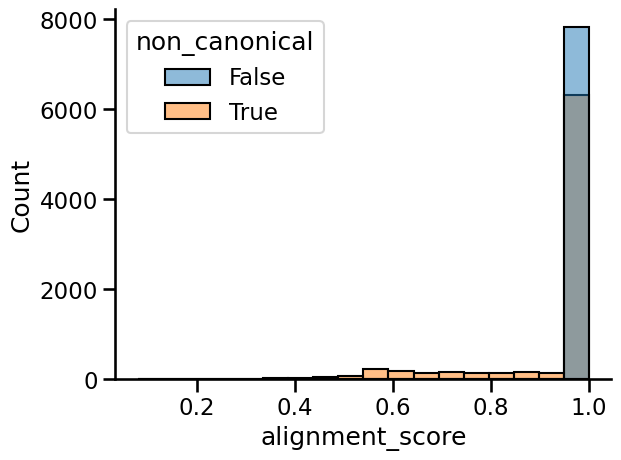

In [16]:
import seaborn as sns
sns.set_context('talk')
sns.histplot(data = DBD_scores, x = 'alignment_score', hue = 'non_canonical', binwidth = 0.05)
sns.despine()

In [17]:
AD_scores = pd.DataFrame({"TF_uniprotID" : AD_TF_isoform_uniprotIDs,
              "AD_seq" : AD_seqs,
              "alignment_score": AD_alignment_scores})
AD_scores

,TF_uniprotID,AD_seq,alignment_score
0,Q9Y5W3,MALSEPILPSFSTFASPCRERGLQERWPRAEPESGGTDDDLNSVLD...,1.0
1,Q8IWI9,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0
3,O60393,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0
...,...,...,...
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0
1890,Q9UM63,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0
1891,Q9UM63-2,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0


In [18]:
AD_scores["non_canonical"] = AD_scores["TF_uniprotID"].str.contains("-")
AD_scores

,TF_uniprotID,AD_seq,alignment_score,non_canonical
0,Q9Y5W3,MALSEPILPSFSTFASPCRERGLQERWPRAEPESGGTDDDLNSVLD...,1.0,False
1,Q8IWI9,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,False
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,True
3,O60393,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,False
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,True
...,...,...,...,...
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True
1890,Q9UM63,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,False
1891,Q9UM63-2,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,True


In [19]:
AD_scores["canonical_TF_uniprotID"] = AD_scores["TF_uniprotID"].str.split("-").str[0]
AD_scores

,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID
0,Q9Y5W3,MALSEPILPSFSTFASPCRERGLQERWPRAEPESGGTDDDLNSVLD...,1.0,False,Q9Y5W3
1,Q8IWI9,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,False,Q8IWI9
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,True,Q8IWI9
3,O60393,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,False,O60393
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,True,O60393
...,...,...,...,...,...
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True,P17040
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True,P17040
1890,Q9UM63,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,False,Q9UM63
1891,Q9UM63-2,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,True,Q9UM63


In [20]:
# Drop these: should be 1
AD_scores[(~AD_scores["non_canonical"]) & (AD_scores["alignment_score"] != 1)]


,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID
55,P20823,LAMDTYSGPPPGPGPGPALPAHSSPGLPPPALSPSKVHGVRYGQPA...,0.997151,False,P20823
120,P10827,MIGACHASRFLHMKVECPTELFPPLFLEVFEDQEV,0.885714,False,P10827
283,O43435,EPLHHHPYKYPAAAYDHYLGAKSRPAPYPLPGLRGHGYHPHAHPHH...,0.643678,False,O43435
391,P10826,MFDCMDVLSVSPGQILDFYTASPSSCMLQEKALKACFSGLTQTEWQ...,0.800000,False,P10826
747,Q96RI1,HLPTTDEFSFSENLFGVLTEQVAGPLGQNLEVEPYSQYSNVQFPQV...,0.910000,False,Q96RI1
918,P10828,HPAAGSNCYMQSTDYYAYFEDSPGYSGCDAQAVPSNNIYMEQAWAV...,0.687500,False,P10828
1321,P16220,MTMESGAENQQSGDAAVTEAENQQMTVQAQPQIATLAQVSMPAAHA...,0.944664,False,P16220
1333,P17861,GNEVRPVAGSAESAAGAGPVVTPPEHLPMDSGGIDSSDSESDILLG...,0.400000,False,P17861
1430,P17544,MGDDRPFVCNAPGCGQRFTNEDHLAVHKHKHEMTLKFGPARTDSVI...,0.962838,False,P17544
1756,Q99081,AAGSSQTGDALGKALASIYSPDHTSSSFPSNPSTPVGSPSPLTGTS...,0.876923,False,Q99081


In [21]:
AD_scores = AD_scores[~((~AD_scores["non_canonical"]) & (AD_scores["alignment_score"] != 1))]
AD_scores

,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID
0,Q9Y5W3,MALSEPILPSFSTFASPCRERGLQERWPRAEPESGGTDDDLNSVLD...,1.0,False,Q9Y5W3
1,Q8IWI9,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,False,Q8IWI9
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.0,True,Q8IWI9
3,O60393,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,False,O60393
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.0,True,O60393
...,...,...,...,...,...
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True,P17040
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.0,True,P17040
1890,Q9UM63,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,False,Q9UM63
1891,Q9UM63-2,SPPEQAAQPMQPLPESLASLHPSVSPGSPPPPLPNHKYNTTSTSYS...,1.0,True,Q9UM63


In [22]:
AD_scores["non_canonical"].value_counts()

non_canonical
True     1267
False     616
Name: count, dtype: int64

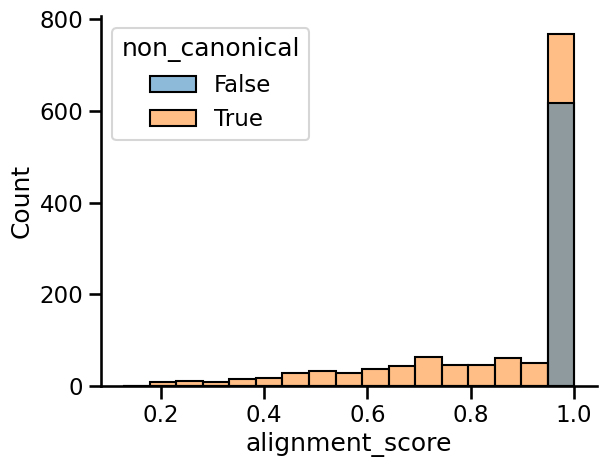

In [23]:
import seaborn as sns
sns.set_context('talk')
sns.histplot(data = AD_scores, x = 'alignment_score', hue = 'non_canonical', binwidth = 0.05)
sns.despine()

# Visualizing Number of total proteoforms vs # affected.

In [24]:
# Splitting ADs into non canonical
non_canonical_ADs = AD_scores[AD_scores["non_canonical"]]
non_canonical_ADs["affected?"] = non_canonical_ADs["alignment_score"] < 1
display(non_canonical_ADs)

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/4209534518.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_canonical_ADs["affected?"] = non_canonical_ADs["alignment_score"] < 1


,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID,affected?
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.000000,True,Q8IWI9,False
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.000000,True,O60393,False
6,Q8WWB7-2,SLEVIPNWLGPLQNLLHIRAVGTNSTLHYVWSSLGPLAVVMVATNT...,0.670588,True,Q8WWB7,True
11,O94983-2,KAHTSPSSSSSSSSSGFAEPLEIRPSPPTSRGGSSRGGTAILLLTG...,1.000000,True,O94983,False
12,O94983-2,SPAPLEPSSRVGRGEALFGGPVGASELEPFSLSSFPDLMGELISDE...,1.000000,True,O94983,False
...,...,...,...,...,...,...
1885,Q9NQV6-7,AVLTTDSATGETVVTTDLLTQAMTELSQTLTTDYRTPQGDYQRIQY...,1.000000,True,Q9NQV6,False
1887,P17040-2,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False


<Axes: xlabel='alignment_score', ylabel='Count'>

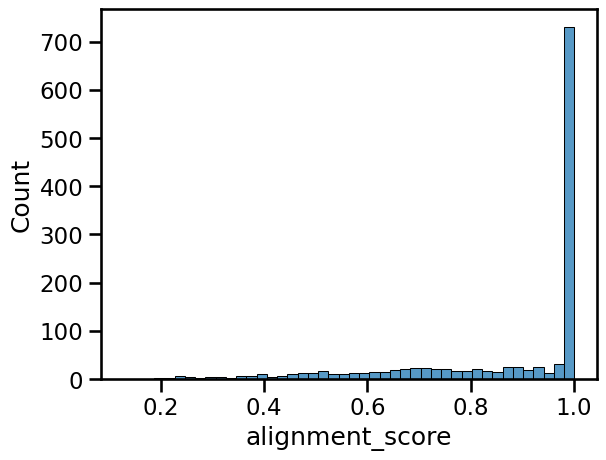

In [25]:
sns.histplot(non_canonical_ADs["alignment_score"], binwidth = 0.02)

In [39]:
non_canonical_ADs

,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID,affected?
2,Q8IWI9-3,DLKDSSIEMELRKVTSAIEEAALDSSELLTNMEDEDDTDETLTSLL...,1.000000,True,Q8IWI9,False
4,O60393-2,NGKESKDNPAAPGPASSQCSSAAEILPAVPMEPKPDPFPQESPLDT...,1.000000,True,O60393,False
6,Q8WWB7-2,SLEVIPNWLGPLQNLLHIRAVGTNSTLHYVWSSLGPLAVVMVATNT...,0.670588,True,Q8WWB7,True
11,O94983-2,KAHTSPSSSSSSSSSGFAEPLEIRPSPPTSRGGSSRGGTAILLLTG...,1.000000,True,O94983,False
12,O94983-2,SPAPLEPSSRVGRGEALFGGPVGASELEPFSLSSFPDLMGELISDE...,1.000000,True,O94983,False
...,...,...,...,...,...,...
1885,Q9NQV6-7,AVLTTDSATGETVVTTDLLTQAMTELSQTLTTDYRTPQGDYQRIQY...,1.000000,True,Q9NQV6,False
1887,P17040-2,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False
1888,P17040-3,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False
1889,P17040-4,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,1.000000,True,P17040,False


In [43]:
AD_results = non_canonical_ADs[["canonical_TF_uniprotID", "affected?", "AD_seq"]].groupby(["canonical_TF_uniprotID", "AD_seq"]).agg(["count", "sum"])
AD_results = AD_results.reset_index()
AD_results.columns = ["uniprotID", "AD_seq", "num_isoforms", "affected_isoforms"]
AD_results["num_isoforms"] += 1
AD_results

,uniprotID,AD_seq,num_isoforms,affected_isoforms
0,A8MZ59,PSAITTANIRPVSPGISDANDHDLREPSGIKNPGGASASARVSSWD...,2,0
1,O00321,MDLWNWDEASPQEVPPGNKLAGLEGAKLGFCFPDLALQGDTPTATA...,2,0
2,O00327,GGTPDIPSSGLLSGQAQENPGYPYSDSSSILGENPHIGIDMIDNDQ...,9,3
3,O00470,IDQSNRAVSQGTPYNPDGQPMGGFVMDGQQHMGIRAPGPMSGMGMN...,2,1
4,O00482,AISMQAEEYLYYKHLNGDVPYNNLLIEMLHAKRA,4,0
...,...,...,...,...
412,Q9Y5R6,SVPTTAASEGRMVIQDIPAVTSRGHVENTPDLVSDSTYYSSFYQPS...,3,1
413,Q9Y692,IPVATLSQGSSPVTVHTLPSGPQLFRYATVVSSAKSSSPDTVTIHP...,2,0
414,Q9Y6Q9,LLQLLTCSSDDRGHSSLTNSPLDSSCKESSVSVTSPSGVSSSTSGG...,5,4
415,Q9Y6Y1,EVLLKSGELQACSSEHYLQPETNGVIRSAGGVPILPGNVVQGLYPV...,4,2


In [45]:
grouped_AD_results = AD_results.groupby(["num_isoforms", "affected_isoforms"]).count().reset_index()#.head(3)
grouped_AD_results["uniprotID"] = grouped_AD_results["uniprotID"].astype(int)
grouped_AD_results["s_norm"] = grouped_AD_results["uniprotID"]/ sum(grouped_AD_results["uniprotID"])
grouped_AD_results

,num_isoforms,affected_isoforms,uniprotID,AD_seq,s_norm
0,2,0,108,108,0.258993
1,2,1,67,67,0.160671
2,3,0,35,35,0.083933
3,3,1,35,35,0.083933
4,3,2,15,15,0.035971
5,4,0,15,15,0.035971
6,4,1,12,12,0.028777
7,4,2,17,17,0.040767
8,4,3,6,6,0.014388
9,5,0,6,6,0.014388


In [46]:
import numpy as np

In [47]:
heatmap_data = pd.crosstab(
    AD_results["affected_isoforms"],
    AD_results["num_isoforms"],
    normalize=True  # Normalize by the total sum
)
heatmap_data = heatmap_data.iloc[::-1]

heatmap_data

num_isoforms,2,3,4,5,6,7,8,9,10,11,12,15,16,17,24,29
affected_isoforms,,,,,,,,,,,,,,,,
28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002398
16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002398,0.000000
12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002398,0.002398,0.002398,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002398,0.002398,0.000000,0.000000,0.000000,0.002398,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004796,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009592,0.002398,0.002398,0.002398,0.007194,0.002398,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.009592,0.000000,0.000000,0.000000,0.000000,0.004796,0.002398,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.007194,0.009592,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='num_isoforms', ylabel='affected_isoforms'>

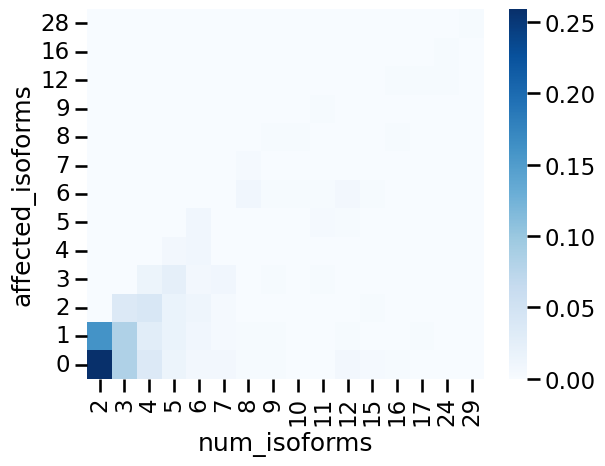

In [48]:
sns.heatmap(data=heatmap_data, cmap="Blues")


In [109]:
grouped_AD_results["adj_affected_isoforms"] = grouped_AD_results["affected_isoforms"].replace({0: 0.5})
grouped_AD_results

,num_isoforms,affected_isoforms,uniprotID,AD_seq,s_norm,adj_affected_isoforms
0,2,0,108,108,0.258993,0.5
1,2,1,67,67,0.160671,1.0
2,3,0,35,35,0.083933,0.5
3,3,1,35,35,0.083933,1.0
4,3,2,15,15,0.035971,2.0
5,4,0,15,15,0.035971,0.5
6,4,1,12,12,0.028777,1.0
7,4,2,17,17,0.040767,2.0
8,4,3,6,6,0.014388,3.0
9,5,0,6,6,0.014388,0.5


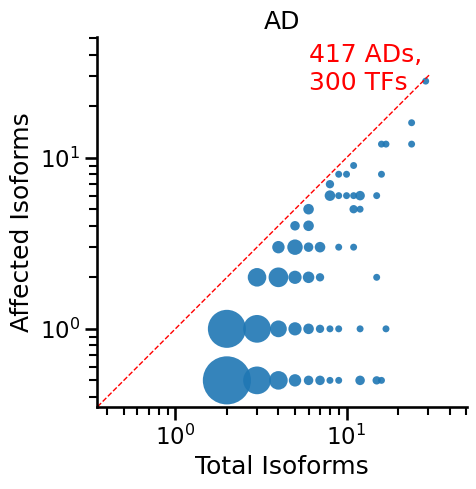

In [147]:
def plot_AD_isoforms(ax):
    sns.scatterplot(data = grouped_AD_results, x = "num_isoforms", y = "adj_affected_isoforms", size= 's_norm', sizes = (25, 1200), 
                    alpha = 0.9, edgecolor = 'none', ax = ax, legend = None)
    sns.despine()
    #ax.set_xlim(0, 10)

    # Add y = x line
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    min_val = min(xlims[0], ylims[0])
    max_val = max(xlims[1], ylims[1])
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

    # Set equal aspect ratio
    ax.set_aspect('equal', adjustable='box')


    ax.set_xscale('log')
    ax.set_yscale('log')


    ax.set_xlim(0.35, 50.5)
    ax.set_ylim(0.35, 50.5)#ax.set_ylim(-1, 50)
    ax.set_xlabel("Total Isoforms")
    ax.set_ylabel("Affected Isoforms")
    ax.set_title("AD")

    # for i in np.arange(0, 15, 1):
    #     ax.axhline(i)

    ax.text(x = 6, y = 25, s = str(len(AD_results)) + " ADs,\n" + str(len(set(AD_results["uniprotID"]))) + " TFs", color = 'red')

fig, ax = plt.subplots()
plot_AD_isoforms(ax)

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/1220299053.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_canonical_DBDs["affected?"] = non_canonical_DBDs["alignment_score"] < 1
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/1220299053.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_canonical_DBDs["canonical_TF_uniprotID"] = non_canonical_DBDs["TF_uniprotID"].str.split("-").str[0]


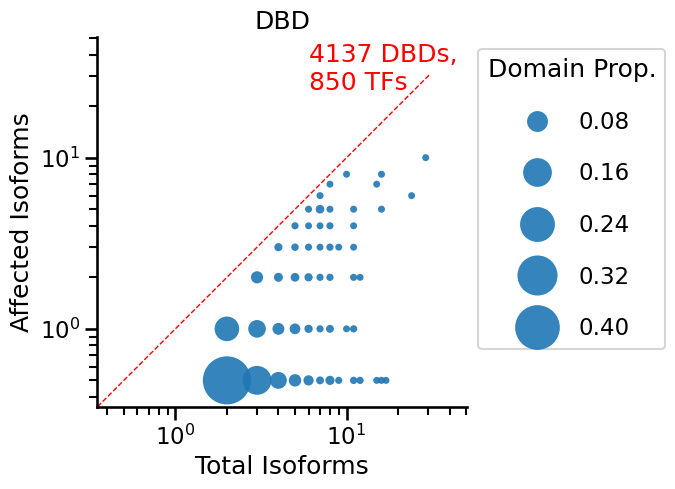

In [125]:
# Splitting DBDs into non canonical
def plot_DBD_isoforms(ax):
    non_canonical_DBDs = DBD_scores[DBD_scores["non_canonical"]]
    non_canonical_DBDs["affected?"] = non_canonical_DBDs["alignment_score"] < 1
    non_canonical_DBDs["canonical_TF_uniprotID"] = non_canonical_DBDs["TF_uniprotID"].str.split("-").str[0]
    #display(non_canonical_DBDs)

    DBD_results = non_canonical_DBDs[["canonical_TF_uniprotID", "affected?", "DBD_seq"]].groupby(["canonical_TF_uniprotID", "DBD_seq"]).agg(["count", "sum"])
    DBD_results = DBD_results.reset_index()
    DBD_results.columns = ["uniprotID", "DBD_seq", "num_isoforms", "affected_isoforms"]
    DBD_results["num_isoforms"] += 1
    DBD_results

# DBD_results = non_canonical_DBDs[["canonical_TF_uniprotID", "affected?"]].groupby("canonical_TF_uniprotID").agg(["count", "sum"])
#     DBD_results = DBD_results.reset_index()
#     DBD_results.columns = ["uniprotID", "num_isoforms", "affected_isoforms"]
#     DBD_results["num_isoforms"] += 1
#     DBD_results

    grouped_DBD_results = DBD_results.groupby(["num_isoforms", "affected_isoforms"]).count().reset_index()#.heDBD(3)
    #display(grouped_DBD_results)
    grouped_DBD_results["uniprotID"] = grouped_DBD_results["uniprotID"].astype(int)
    grouped_DBD_results["s_norm"] = grouped_DBD_results["uniprotID"]/ sum(grouped_DBD_results["uniprotID"])
    #display(grouped_DBD_results)
    grouped_DBD_results["adj_affected_isoforms"] = grouped_DBD_results["affected_isoforms"].replace({0: 0.5})


    sns.scatterplot(data = grouped_DBD_results, x = "num_isoforms", y = "adj_affected_isoforms", size= 's_norm', sizes = (25, 1200), 
                alpha = 0.9, edgecolor = 'none', ax = ax, legend = 'brief')

    sns.despine()
    #ax.set_xlim(0, 10)

    #  y = x line
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    min_val = min(xlims[0], ylims[0])
    max_val = max(xlims[1], ylims[1])
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

    # Set equal aspect ratio
    #


    ax.set_xscale('log')
    ax.set_yscale('log')


    ax.set_xlim(0.35, 50.5)
    ax.set_ylim(0.35, 50.5)#ax.set_ylim(-1, 50)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel("Total Isoforms")
    ax.set_ylabel("Affected Isoforms")
    ax.set_title("DBD");
    ax.text(x = 6, y = 25, s = str(len(DBD_results)) + " DBDs,\n" + str(len(set(DBD_results["uniprotID"]))) + " TFs", color = 'red')
    ax.legend(title="Domain Prop.", bbox_to_anchor = (1,1), labelspacing=1.25)

fig, ax = plt.subplots()
plot_DBD_isoforms(ax)

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/3018548725.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_canonical_DBDs["affected?"] = non_canonical_DBDs["alignment_score"] < 1
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_94191/3018548725.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_canonical_DBDs["canonical_TF_uniprotID"] = non_canonical_DBDs["TF_uniprotID"].str.split("-").str[0]


Text(0.5, 0.01, 'Total Isoforms')

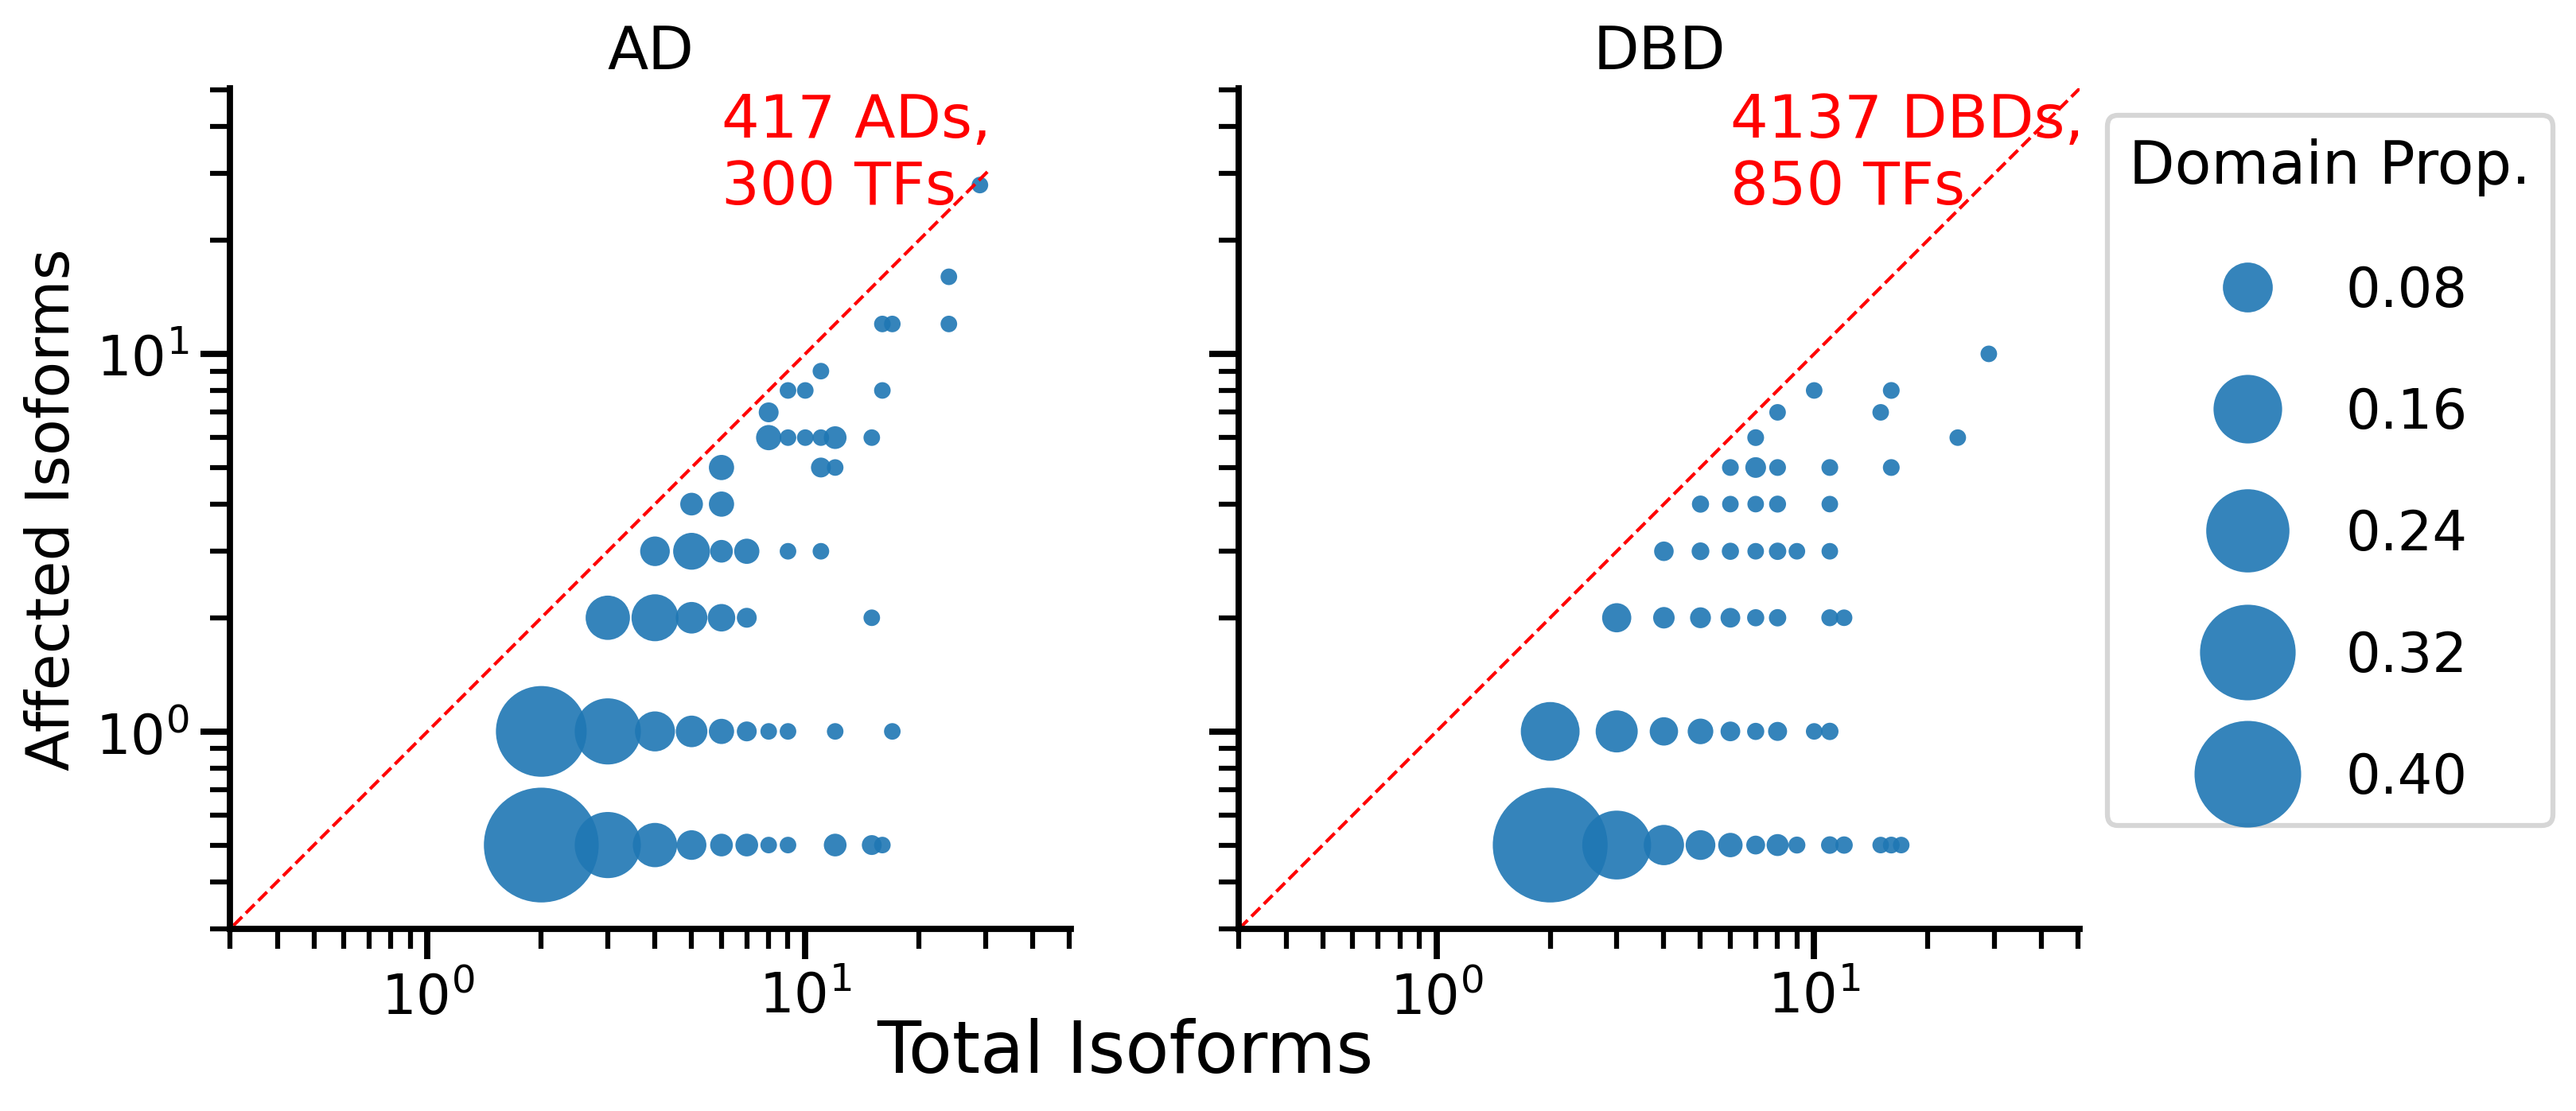

In [123]:
fig, axs = plt.subplots(1, 2, sharey = True, sharex = True, figsize = (10,5), dpi = 300)
plot_AD_isoforms(axs[0])
plot_DBD_isoforms(axs[1])
axs[0].set_xlabel("")
axs[1].set_xlabel("")
fig.supxlabel("Total Isoforms", y = 0.01)

In [34]:
AD_results[AD_results["num_isoforms"] > 20].sort_values(by = "num_isoforms", ascending = False)

,uniprotID,num_isoforms,affected_isoforms
190,Q14934,47,28
39,P04150,43,8
25,O75030,34,1
273,Q9NQB0,33,13
70,P15884,31,12
157,Q03060,29,28
13,O15350,23,5
266,Q9H3D4,23,12
135,P53539,21,11
149,Q01196,21,8


In [35]:
DBD_results[DBD_results["num_isoforms"] > 20].sort_values(by = "num_isoforms", ascending = False)

NameError: name 'DBD_results' is not defined

# As # of alternative isoforms changes, how does relative proportion of affected isoforms (DBD vs AD vs both) change?

In [297]:
non_canonical_ADs

,TF_uniprotID,AD_seq,alignment_score,non_canonical,canonical_TF_uniprotID,affected?
1,P57082-2,RHLDLPCKRSYLEAPSSVGEDHYFRSPPPYDQQMLSPSYCSEVTPR...,1.000000,True,P57082,False
4,P11473-2,DMMDSSSFSNLDLSEEDSDDPSVTLELSQLSMLPHLADLVSYSI,1.000000,True,P11473,False
5,P11473-2,TPLVLEVFGNEIS,1.000000,True,P11473,False
7,P78413-2,HELNSAAALGVYGGPYGGSQGYGNYVTYGSEASAFYSLNSFDSKDG...,1.000000,True,P78413,False
9,Q9UL68-3,EEEEEEEEEEEEEEEENEDHQMNCHNTRIMQDTEKDDNNNDEYDNY...,0.270073,True,Q9UL68,True
...,...,...,...,...,...,...
1872,Q2QGD7-3,DSPLVLGTAATVLQQGSFSVDDVQTVSAGALGCLVALPMKNLSDDP...,0.693122,True,Q2QGD7,True
1874,O75444-1,MASELAMSNSDLPTSPLAMEYVNDFDLMKFEVKKEPVETDRIISQC...,1.000000,True,O75444,False
1882,P32519-2,MAAVVQQNDLVFEFASNVMEDERQLGDPAIFPAVIVEHVPGADILN...,1.000000,True,P32519,False
1886,P26367-2,LRNQRRQASNTPSHIPISSSFSTSVYQPIPQPTTPVSSFTSGSMLG...,1.000000,True,P26367,False


In [298]:
non_canonical_DBDs

,TF_uniprotID,DBD_seq,alignment_score,non_canonical,affected?,canonical_TF_uniprotID
14,Q7Z7L9-3,ECPQCGKTFSRKSHLITHERTH,0.590909,True,True,Q7Z7L9
15,Q7Z7L9-3,KCDECGKSFSDGSNFSRHQTTH,0.590909,True,True,Q7Z7L9
16,Q7Z7L9-3,KCRDCGKSFSRSANLITHQRIH,0.590909,True,True,Q7Z7L9
17,Q7Z7L9-3,QCAECGKSFSRSPNLIAHQRTH,0.681818,True,True,Q7Z7L9
18,Q7Z7L9-3,SCPECGKSFGNRSSLNTHQGIH,0.590909,True,True,Q7Z7L9
...,...,...,...,...,...,...
15572,P56270-4,ACEMCGKAFRDVYHLNRHKLSH,0.681818,True,True,P56270
15573,P56270-4,QCPVCQQRFKRKDRMSYHVRSH,0.818182,True,True,P56270
15574,P56270-4,NCSHCGKSFSRPDHLNSHVRQVH,0.695652,True,True,P56270
15575,P56270-4,KCEKCEAAFATKDRLRAHTVRH,0.954545,True,True,P56270


In [301]:
isoforms_set = set(non_canonical_ADs["TF_uniprotID"]) or set(non_canonical_DBDs["TF_uniprotID"])
len(isoforms_set)

866

In [ ]:
for uniprotID in isoforms_set:
    

,TF_uniprotID,AD_seq,alignment_score_x,non_canonical_x,canonical_TF_uniprotID_x,affected?_x,DBD_seq,alignment_score_y,non_canonical_y,affected?_y,canonical_TF_uniprotID_y
0,P57082-2,RHLDLPCKRSYLEAPSSVGEDHYFRSPPPYDQQMLSPSYCSEVTPR...,1.000000,True,P57082,False,GLHEKELWKKFHEAGTEMIITKAGRRMFPSYKVKVTGMNPKTKYIL...,1.000000,True,False,P57082
1,P11473-2,DMMDSSSFSNLDLSEEDSDDPSVTLELSQLSMLPHLADLVSYSI,1.000000,True,P11473,False,ICGVCGDRATGFHFNAMTCEGCKGFFRRSMKRKALFTCPFNGDCRI...,1.000000,True,False,P11473
2,P11473-2,TPLVLEVFGNEIS,1.000000,True,P11473,False,ICGVCGDRATGFHFNAMTCEGCKGFFRRSMKRKALFTCPFNGDCRI...,1.000000,True,False,P11473
3,P78413-2,HELNSAAALGVYGGPYGGSQGYGNYVTYGSEASAFYSLNSFDSKDG...,1.000000,True,P78413,False,RRKNATRETTSTLKAWLQEHRKNPYPTKGEKIMLAIITKMTLTQVS...,1.000000,True,False,P78413
4,Q9UL68-3,EEEEEEEEEEEEEEEENEDHQMNCHNTRIMQDTEKDDNNNDEYDNY...,0.270073,True,Q9UL68,True,CPTPGCDGSGHVSGKYARHRSVYGCPLA,0.857143,True,True,Q9UL68
...,...,...,...,...,...,...,...,...,...,...,...
2152,O75444-1,MASELAMSNSDLPTSPLAMEYVNDFDLMKFEVKKEPVETDRIISQC...,1.000000,True,O75444,False,RLKQKRRTLKNRGYAQSCRFKRVQQRHVLESEKNQLLQQVDHLKQE...,1.000000,True,False,O75444
2153,P32519-2,MAAVVQQNDLVFEFASNVMEDERQLGDPAIFPAVIVEHVPGADILN...,1.000000,True,P32519,False,LWEFLLALLQDKATCPKYIKWTQREKGIFKLVDSKAVSRLWGKHKN...,1.000000,True,False,P32519
2154,P26367-2,LRNQRRQASNTPSHIPISSSFSTSVYQPIPQPTTPVSSFTSGSMLG...,1.000000,True,P26367,False,HSGVNQLGGVFVNGRPLPDSTRQKIVELAHSGARPCDISRILQVSN...,1.000000,True,False,P26367
2155,P26367-2,LRNQRRQASNTPSHIPISSSFSTSVYQPIPQPTTPVSSFTSGSMLG...,1.000000,True,P26367,False,RNRTSFTQEQIEALEKEFERTHYPDVFARERLAAKIDLPEARIQVW...,1.000000,True,False,P26367


# Do TFs with ADs have more isoforms?

In [351]:
known_ADs["canonical_uniprotID"] = known_ADs["uniprotID"].str.split("-").str[0]
known_ADs

,Unnamed: 0,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,AD_seq,canonical_uniprotID
0,0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,"DelRosso et al. (Q6UWZ7, 121_200)",CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...,Q6UWZ7
1,1,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,LLQALNGFV,P35869
2,2,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,FAI,P35869
3,3,AHR,532,848,P35869,"[['P35869'], ['P35869'], ['P35869']]",ENST00000242057 / nan / ENST00000242057,P35869 / P35869 / P35869,"DelRosso et al. (P35869, 532_641) // PMID: 879...",TF / TF / TF,QDSKNSDLYSIMKNLGIDFEDIRHMQNEKFFRNDFSGEVDFRDIDL...,P35869
4,4,AKAP8,2,81,O43823,[['O43823']],ENST00000269701,O43823,"DelRosso et al. (O43823, 2_81)",TF,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...,O43823
...,...,...,...,...,...,...,...,...,...,...,...,...
756,757,ATXN7L3,1,120,Q14CW9,"[['Q14CW9', 'Q14CW9-2']]",NaN,NaN,Alerasool et al,TF,MKMEEMSLSGLDNSKLEAIAQEIYADLVEDSCLGFCFEVHRAVKCG...,Q14CW9
757,758,FAM22F,361,500,A1L443,[['A1L443']],NaN,NaN,Alerasool et al,TF,PRPQRPAETNAHLPPPRPQRPAETKVPEEIPPEVVQEYVDIMEELL...,A1L443
758,759,SS18L2,18,77,Q9UHA2,[['Q9UHA2']],NaN,NaN,Alerasool et al,TF,QETIQRLLEENDQLIRCIVEYQNKGRGNECVQYQHVLHRNLIYLAT...,Q9UHA2
759,760,SERTAD2,201,260,Q14140,[['Q14140']],NaN,NaN,Alerasool et al,TF,SEAGTQKLDGPQESRADDSKLMDSLPGNFEITTSTGFLTDLTLDDI...,Q14140


In [352]:
lambert_isoforms["activator_TF"] = lambert_isoforms["canonical_uniprotID"].isin(known_ADs["canonical_uniprotID"])
lambert_isoforms

,id,seq,uniprotID,canonical_uniprotID,activator_TF
0,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,A0AVK6,A0AVK6,False
1,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2,A0PJY2,False
2,sp|A0PJY2-2|FEZF1_HUMAN Isoform 2 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2-2,A0PJY2,False
3,sp|A0PJY2-3|FEZF1_HUMAN Isoform 3 of Fez famil...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,A0PJY2-3,A0PJY2,False
4,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,A1A519,A1A519,False
...,...,...,...,...,...
3526,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,Q9Y6X8,Q9Y6X8,False
3527,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1,Q9Y6Y1,True
3528,sp|Q9Y6Y1-2|CMTA1_HUMAN Isoform 2 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1-2,Q9Y6Y1,True
3529,sp|Q9Y6Y1-3|CMTA1_HUMAN Isoform 3 of Calmoduli...,MWRAEGKWLPKTSRKSVSQSVFCGTSTYCVLNTVPPIEDDHGNSNS...,Q9Y6Y1-3,Q9Y6Y1,True


In [354]:
isoform_counts = pd.DataFrame(lambert_isoforms.groupby("canonical_uniprotID").size()).reset_index()
isoform_counts["activator_TF"] = isoform_counts["canonical_uniprotID"].isin(known_ADs["canonical_uniprotID"])
isoform_counts

,canonical_uniprotID,0,activator_TF
0,A0AVK6,1,False
1,A0PJY2,3,False
2,A1A519,4,False
3,A1YPR0,1,False
4,A2RRD8,1,False
...,...,...,...
1603,Q9Y6Q9,5,True
1604,Q9Y6R6,1,False
1605,Q9Y6X0,2,False
1606,Q9Y6X8,1,False


In [384]:
max(isoform_counts[0])

29

Text(0.5, 0, 'Number of Isoforms')

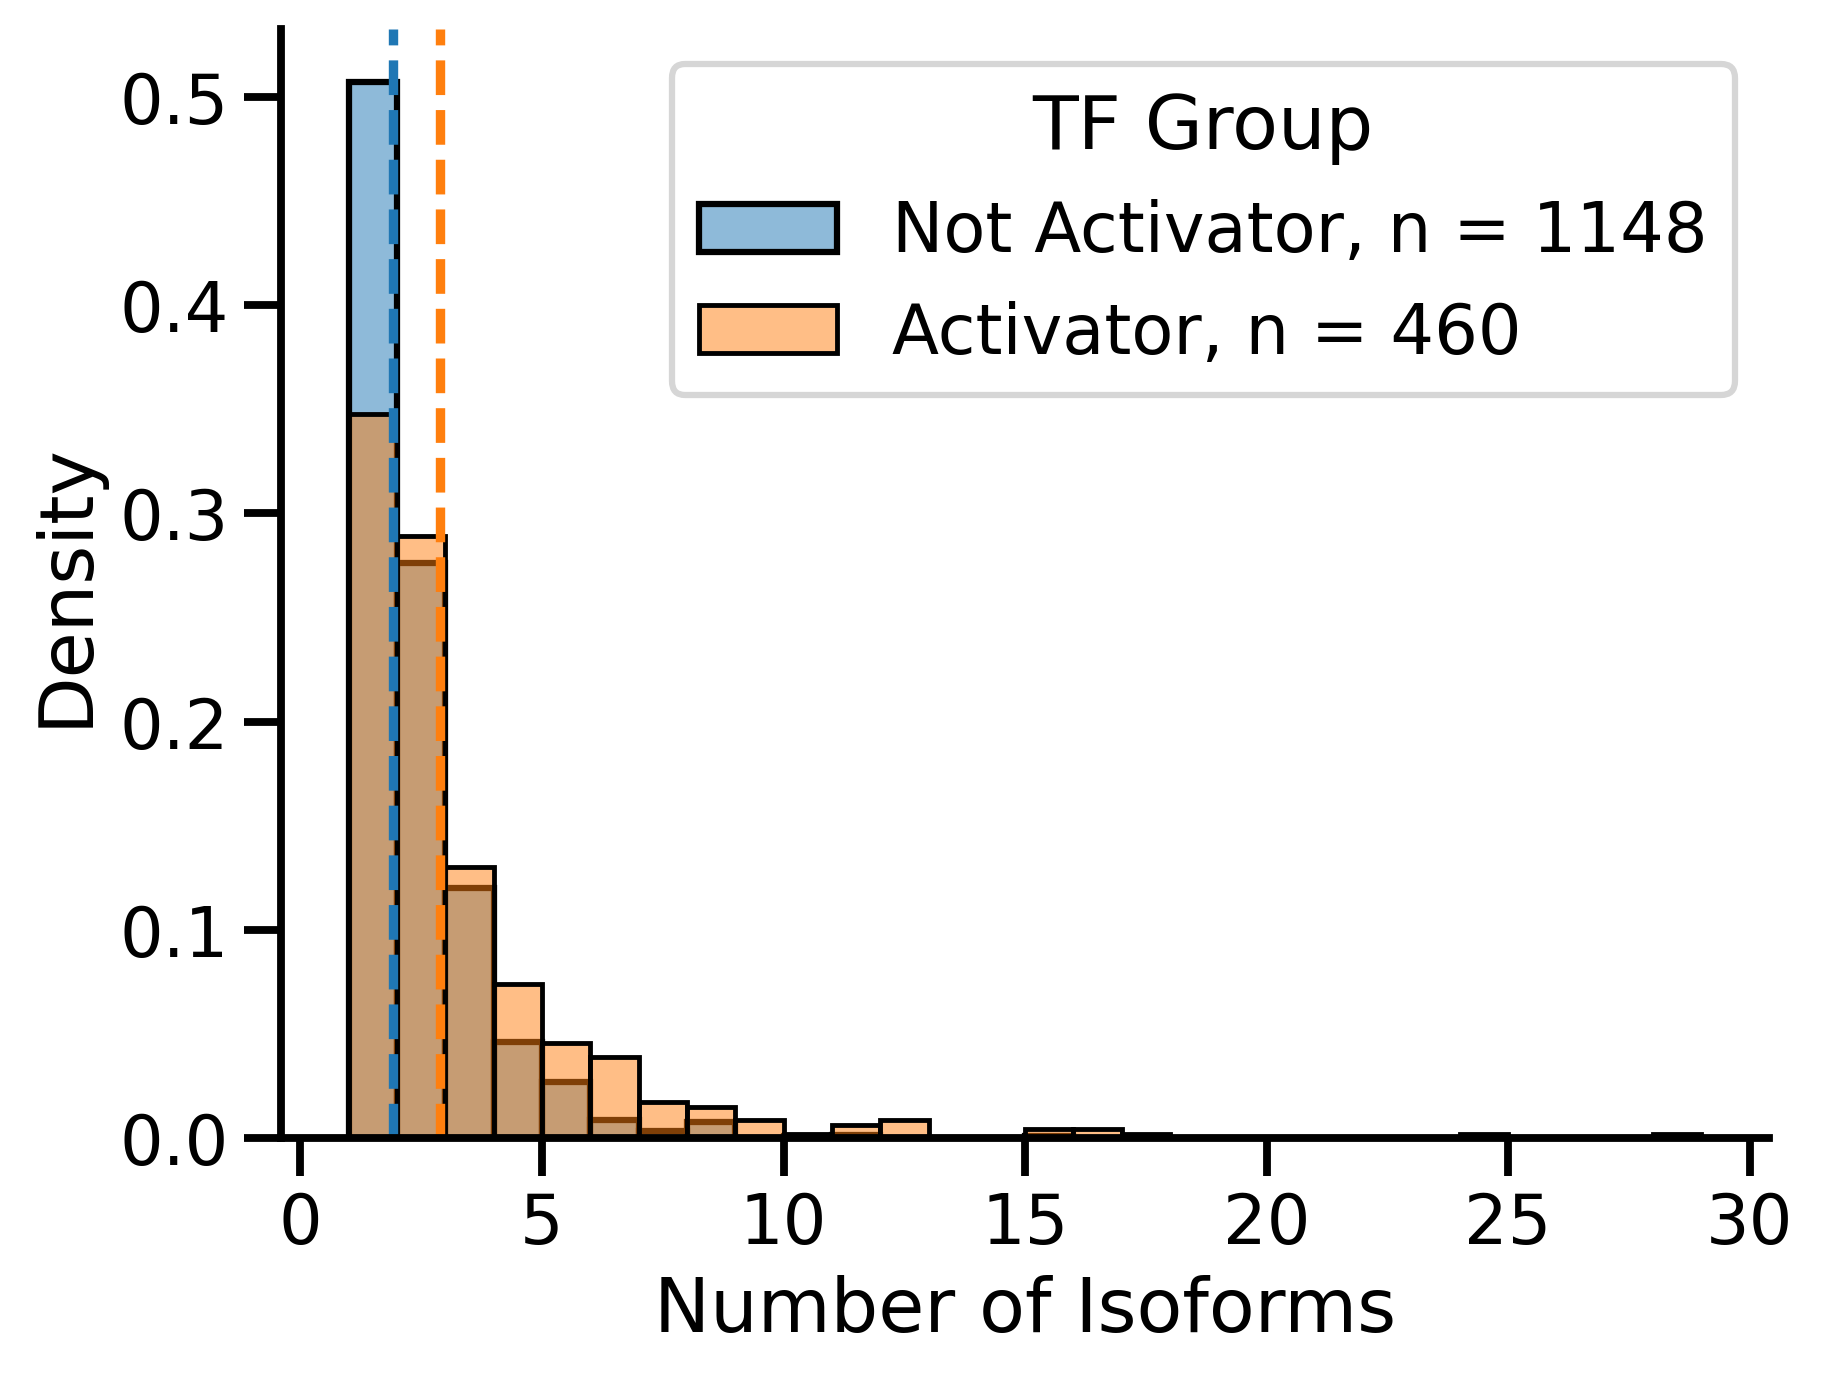

In [383]:
plt.figure(dpi = 300)

sns.histplot(data = isoform_counts[~isoform_counts["activator_TF"]], x = 0, stat = 'density', 
             label = 'Not Activator, n = ' + str(len(isoform_counts[~isoform_counts["activator_TF"]])), binwidth = 1, alpha = 0.5)
plt.axvline(np.mean(isoform_counts[~isoform_counts["activator_TF"]][0]), color = sns.color_palette('tab10')[0], linestyle = "dashed")

sns.histplot(data = isoform_counts[isoform_counts["activator_TF"]], x = 0, stat = 'density', 
             label = 'Activator, n = ' + str(len(isoform_counts[isoform_counts["activator_TF"]])), binwidth = 1, alpha = 0.5)
plt.axvline(np.mean(isoform_counts[isoform_counts["activator_TF"]][0]), color = sns.color_palette('tab10')[1], linestyle = "dashed")

sns.despine()
plt.legend(title = "TF Group")
plt.xlabel("Number of Isoforms")

# 4. For each TF, save DBD annotations where Levenshtein distance is <10% of DBD length.

In [64]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

def return_prop_domain_aligned(domain_seq, full_prot):
    if domain_seq in full_prot:
        return 1
    else:
        alignments = pairwise2.align.globalxx(domain_seq, full_prot)
        best_score = alignments[0].score
        #print(format_alignment(*alignments[0]))
        return best_score / len(domain_seq)


In [84]:
known_ADs["test"] = known_ADs["ProteinRegionSeq"].apply(lambda s: return_prop_domain_aligned(s, lambert_isoforms["seq"].iloc[553]))
known_ADs

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq,test
0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,"DelRosso et al. (Q6UWZ7, 121_200)",CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...,0.625000
1,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,LLQALNGFV,1.000000
2,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL (P358...",TF,FAI,1.000000
3,AHR,532,848,P35869,"[['P35869'], ['P35869'], ['P35869']]",ENST00000242057 / nan / ENST00000242057,P35869 / P35869 / P35869,"DelRosso et al. (P35869, 532_641) // PMID: 879...",TF / TF / TF,QDSKNSDLYSIMKNLGIDFEDIRHMQNEKFFRNDFSGEVDFRDIDL...,0.353312
4,AKAP8,2,81,O43823,[['O43823']],ENST00000269701,O43823,"DelRosso et al. (O43823, 2_81)",TF,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...,0.600000
...,...,...,...,...,...,...,...,...,...,...,...
757,ATXN7L3,1,120,Q14CW9,"[['Q14CW9', 'Q14CW9-2']]",NaN,NaN,Alerasool et al,TF,MKMEEMSLSGLDNSKLEAIAQEIYADLVEDSCLGFCFEVHRAVKCG...,0.541667
758,FAM22F,361,500,A1L443,[['A1L443']],NaN,NaN,Alerasool et al,TF,PRPQRPAETNAHLPPPRPQRPAETKVPEEIPPEVVQEYVDIMEELL...,0.542857
759,SS18L2,18,77,Q9UHA2,[['Q9UHA2']],NaN,NaN,Alerasool et al,TF,QETIQRLLEENDQLIRCIVEYQNKGRGNECVQYQHVLHRNLIYLAT...,0.733333
760,SERTAD2,201,260,Q14140,[['Q14140']],NaN,NaN,Alerasool et al,TF,SEAGTQKLDGPQESRADDSKLMDSLPGNFEITTSTGFLTDLTLDDI...,0.766667


In [82]:
lambert_isoforms[lambert_isoforms["id"].str.contains("ERG")]

,id,seq
548,sp|P11308|ERG_HUMAN Transcriptional regulator ...,MASTIKEALSVVSEDQSLFECAYGTPHLAKTEMTASSSSDYGQTSK...
549,sp|P11308-1|ERG_HUMAN Isoform 3 of Transcripti...,MIQTVPDPAAHIKEALSVVSEDQSLFECAYGTPHLAKTEMTASSSS...
550,sp|P11308-2|ERG_HUMAN Isoform 4 of Transcripti...,MVGSPDTVGMNYGSYMEEKHMPPPNMTTNERRVIVPADPTLWSTDH...
551,sp|P11308-3|ERG_HUMAN Isoform 2 of Transcripti...,MIQTVPDPAAHIKEALSVVSEDQSLFECAYGTPHLAKTEMTASSSS...
552,sp|P11308-5|ERG_HUMAN Isoform 5 of Transcripti...,MIQTVPDPAAHIKEALSVVSEDQSLFECAYGTPHLAKTEMTASSSS...
553,sp|P11308-6|ERG_HUMAN Isoform 6 of Transcripti...,MIQTVPDPAAHIKEALSVVSEDQSLFECAYGTPHLAKTEMTASSSS...


In [83]:
known_ADs[known_ADs["uniprotID"] == "P11308"]

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq,test
60,ERG,118,261,P11308,"[['P11308-1', 'P11308-3', 'P11308-5', 'P11308-...",nan / ENST00000288319,P11308 / P11308,"PMID: 14603248, Soto (P11308, 125_209) // DelR...",TF / TF,MTTNERRVIVPADPTLWSTDHVRQWLEWAVKEYGLPDVNILLFQNI...,0.409722
61,ERG,433,479,P11308,[['P11308-3']],NaN,P11308,"PMID: 9681824, Soto (P11308, 440_486)",TF,PHPPALPVTSSSFFAAPNPYWNSPTGGIYPNTRLPTSHMPSHLGTYY,0.617021


In [86]:
known_ADs.sort_values(by = 'test', ascending = False)[:40]

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq,test
564,NKX2-5,10,21,P52952,"[['P52952', 'P52952-2', 'P52952-3']]",NaN,P52952,"PMID: 25503402, Soto (P52952, 10_21)",TF,TPFSVKDILNLE,1.000000
382,VDR,415,427,P11473,[['P11473']],NaN,P11473,"PMID: 15908514, Soto (P11473, 415_427)",TF,TPLVLEVFGNEIS,1.000000
489,HOXB7,206,217,P09629,[['P09629']],NaN,P09629,"PMID: 10435624, Soto (P09629, 206_217)",TF,QDRAEAEEEEEE,1.000000
706,THRB,453,461,P10828,[['P10828']],NaN,P10828,"PMID: 7983057, Soto (P10828, 453_461)",TF,PLFLEVFED,1.000000
447,FOXJ2,1,27,Q9P0K8,"[['Q9P0K8', 'Q9P0K8-2']]",NaN,Q9P0K8,"PMID: 12787665, Soto (Q9P0K8, 1_27)",TF,MASDLESSLTSIDWLPQLTLRATIEKL,1.000000
189,PPARG,495,503,P37231,[['P37231']],NaN,P37231,"PMID: 19596783, Soto (P37231, 495_503)",TF,PLLQEIYKD,1.000000
502,c-Jun/AP-1,238,257,P05412,[['P05412']],NaN,P05412,"Choi 2000 list, GSL (P05412, 238_257)",TF,ETPPLSPIDMESQERIKAER,1.000000
513,KLF9,13,27,Q13886,[['Q13886']],NaN,Q13886,"PMID: 7775404, Soto (Q13886, 13_27)",TF,QCLVSISNRAAVPEH,1.000000
514,KLF9,58,68,Q13886,[['Q13886']],NaN,Q13886,"PMID: 7775404, Soto (Q13886, 58_68)",TF,CTLVTIAKSLL,1.000000
738,TFEB,156,165,P19484,[['P19484']],NaN,P19484,"activation_regions.txt, GSL (P19484, 156_165)",TF,ELDDVIDNIM,1.000000


In [ ]:
# New plan: align each AD sequence to 

In [51]:
for seq in DBD_sql_dump["ProtFeature_Sequence"]:
    if seq in lambert_isoforms.iloc[10]["seq"]:
        print(seq)

KKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKR
FSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKR


In [60]:
return_prop_domain_aligned("KKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKR", lambert_isoforms.iloc[10]["seq"])

---K----K-----------T-------------R-------------------------------------------------------T---------------------------------------------------------------VFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKR-------------------------------------------------------------------
   |    |           |             |                                                       |                                                               ||||||||||||||||||||||||||||||||||||||||||||||||||||                                                                   
MGSKEDAGKGCPAAGGVSSFTIQSILGGGPSEAPREPVGWPARKRSLSVSSEEEEPDDGWKAPACFCPDQHGPKEQGPKHHPPIPFPCLGTPKGSGGSGPGGLERTPFLSPSHSDFKEEKERLLPAGSPSPGSERPRDGGAERQAGAAKKKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKRQLSAELEAANMAHASAQTLVSMPLVFRDSSLLRVPVPRSLAFPAPLYYPGSNLSALPLYNLYNKLDY
  Score=57



1.0

In [53]:
DBD_sql_dump[DBD_sql_dump["ProtFeature_Sequence"] == "KKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKR"]

,Unnamed: 0,PFeature_ID,Protein_ID,Domain_ID,ProtFeature_FromPos,ProtFeature_ToPos,ProtFeature_Sequence,Domain_Name,Pfam_Name,Pfam_DBID,Inter_DBID,Domain_Type,test
745772,745772,PF745773_2.00,P231408_2.00,D40_2.00,151,207,KKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKT...,Homeodomain,Homeobox,PF00046,IPR001356,DBD,0.052632


In [47]:
DBD_sql_dump.sort_values(by = 'test')

,Unnamed: 0,PFeature_ID,Protein_ID,Domain_ID,ProtFeature_FromPos,ProtFeature_ToPos,ProtFeature_Sequence,Domain_Name,Pfam_Name,Pfam_DBID,Inter_DBID,Domain_Type,test
947284,947284,PF947285_2.00,P392502_2.00,D84_2.00,1,3664,MVRETRHLWVGNLPENVREEKIIEHFKRYGRVESVKILPKRGSEGG...,Unknown,UNKNOWN,Unknown,Unknown,DBD,0.000819
947499,947499,PF947500_2.00,P392720_2.00,D84_2.00,1,2426,MATNIEQIFRSFVVSKFREIQQELSSGRNEGQLNGETNTPIEGNQA...,Unknown,UNKNOWN,Unknown,Unknown,DBD,0.001237
947502,947502,PF947503_2.00,P392723_2.00,D84_2.00,1,2325,MATNIEQIFRSFVVSKFREIQQELSSGRNEGQLNGETNTPIEGNQA...,Unknown,UNKNOWN,Unknown,Unknown,DBD,0.001290
947498,947498,PF947499_2.00,P392719_2.00,D84_2.00,1,2303,MATNIEQIFRSFVVSKFREIQQELSSGRNEGQLNGETNTPIEGNQA...,Unknown,UNKNOWN,Unknown,Unknown,DBD,0.001303
947491,947491,PF947492_2.00,P392712_2.00,D84_2.00,1,2301,MDSLAGLSPREAAGVLSLSCVGVCSTCAWAWPHGSMRDLRAQVTSG...,Unknown,UNKNOWN,Unknown,Unknown,DBD,0.001304
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22927,22927,PF022928_2.00,P018923_2.00,D07_2.00,257,263,PKKRGRP,AT hook,AT_hook,PF02178,IPR017956,DBD,0.428571
23911,23911,PF023912_2.00,P019262_2.00,D07_2.00,31,37,VKKRGRP,AT hook,AT_hook,PF02178,IPR017956,DBD,0.428571
24293,24293,PF024294_2.00,P019365_2.00,D07_2.00,140,145,KKGRGR,AT hook,AT_hook,PF02178,IPR017956,DBD,0.500000
22472,22472,PF022473_2.00,P018785_2.00,D07_2.00,40,45,KRPRGR,AT hook,AT_hook,PF02178,IPR017956,DBD,0.500000


In [50]:
lambert_isoforms.iloc[10]["seq"]

'MGSKEDAGKGCPAAGGVSSFTIQSILGGGPSEAPREPVGWPARKRSLSVSSEEEEPDDGWKAPACFCPDQHGPKEQGPKHHPPIPFPCLGTPKGSGGSGPGGLERTPFLSPSHSDFKEEKERLLPAGSPSPGSERPRDGGAERQAGAAKKKTRTVFSRSQVYQLESTFDMKRYLSSSERACLASSLQLTETQVKTWFQNRRNKWKRQLSAELEAANMAHASAQTLVSMPLVFRDSSLLRVPVPRSLAFPAPLYYPGSNLSALPLYNLYNKLDY'